# RQ1 --- Effectiveness

In [1]:
import sys

sys.path.insert(0, "..")
import numpy as np
from experiments._loader import load_all_results, success_only
from experiments._analysis import (
    PALETTE,
    tex,
    setup_matplotlib,
    compute_image_metrics,
    compute_text_metrics,
    classify_termination_series,
    add_cumulative_asr_outcomes,
    compute_swad,
    TERMINATION_COLORS,
    TERMINATION_ORDER,
)
import matplotlib.pyplot as plt
import pandas as pd

setup_matplotlib()

df_all = load_all_results(include_baseline_fail=True)
df_opt = success_only(df_all)

THRESHOLDS = np.arange(0.0, 1.1, 0.1)  # 0.0, 0.1, ..., 0.9

MODEL_MAPPING = {
    "qwen": "Qwen3-VL",
    "kimi": "Kimi-VL",
    "intern": "InternVL3.5",
    "gemma": "Gemma3",
    "deepseek": "DeepseekVL2",
    "nemotron": "Nemotron3-ON",
}

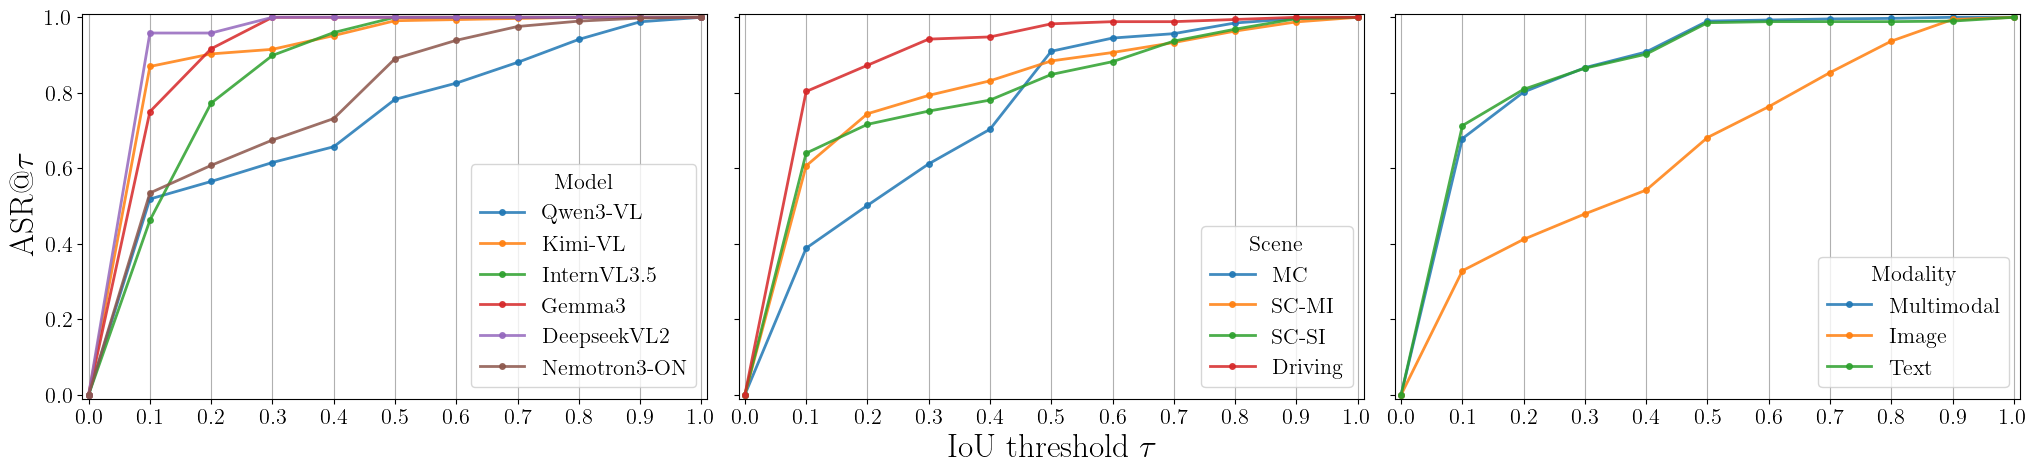

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5), sharey=True)
fig.subplots_adjust(wspace=0.05)

# 1) By model
ax = axes[0]

for i, (model, alias) in enumerate(MODEL_MAPPING.items()):
    sub = df_opt[df_opt["model"] == model]
    if df_opt[df_opt["model"] == model].size < 30:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] < t).mean() for t in THRESHOLDS],
        lw=2,
        label=tex(alias),
        color=PALETTE[i],
        alpha=0.85,
        marker="o",
        markersize=4,
    )
##ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_ylabel(r"ASR@$\tau$", fontsize=24)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Model")
ax.grid(axis="x")

# 2) By scene
SCENE_ALIAS = {
    "multi": "MC",
    "single/multi": "SC-MI",
    "single/solo": "SC-SI",
    "udacity": "Driving"
}

ax = axes[1]
for scene, label in SCENE_ALIAS.items():
    sub = df_opt[df_opt["obj_category"] == scene]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] < t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker="o",
        markersize=4,
    )
ax.set_xlabel(r"IoU threshold $\tau$", fontsize=24)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Scene")
ax.grid(axis="x")

# 3) By modality
MODALITY_ALIAS = {
    "multi": "Multimodal",
    "image": "Image",
    "text": "Text",
}

ax = axes[2]
for modality, label in MODALITY_ALIAS.items():
    sub = df_opt[df_opt["genome_mode"] == modality]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] < t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker="o",
        markersize=4,
    )
# ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Modality")
ax.grid(axis="x")
plt.savefig("figures/curves_rq1.pdf", dpi=200, bbox_inches="tight")

In [3]:
df_opt = compute_swad(compute_image_metrics(df_opt))
df_asr = add_cumulative_asr_outcomes(df_opt, iou_threshold=0.25)
df_txt = compute_text_metrics(df_opt[df_opt["genome_mode"].isin(["multi", "text"])].copy())

SCENES = [("MC", "multi"), ("SC-MI", "single/multi"), ("SC-SI", "single/solo"), ("Driving", "udacity")]
GENOME_MODES = ["multi", "image", "text"]


def format_mean_std(mean: float, std: float, decimals: int = 3) -> str:
    if pd.isna(mean):
        return "---"
    std = 0.0 if pd.isna(std) else std
    return f"${mean:.{decimals}f} \\pm {std:.{decimals}f}$"


def format_rate(values: pd.Series) -> tuple[str, float, int]:
    values = values.dropna().astype(bool)
    n = len(values)
    successes = int(values.sum())
    if n == 0:
        return "---", np.nan, 0
    return f"{successes / n:.3f} ({successes}/{n})", successes / n, n


records = []
for model in sorted(df_all["model"].dropna().unique()):
    for scene, obj_category in SCENES:
        for genome_mode in GENOME_MODES:
            sub_all = df_all[(df_all["model"] == model) & (df_all["genome_mode"] == genome_mode) & (df_all["obj_category"] == obj_category)]
            sub_opt = df_asr[(df_asr["model"] == model) & (df_asr["genome_mode"] == genome_mode) & (df_asr["obj_category"] == obj_category)]
            n_total = len(sub_all)
            n_baseline_fail = int(sub_all["status"].eq("baseline_fail").sum())
            fail_rate = n_baseline_fail / n_total if n_total else np.nan
            record = {
                "model": model, "scene": scene, "genome_mode": genome_mode,
                "n_opt": len(sub_opt),
                "baseline_fail": "---" if not n_total else f"{fail_rate:.3f} ({n_baseline_fail}/{n_total})",
                "fail_rate": fail_rate,
                "asr_bbox": "---", "asr_bbox_empty": "---", "asr_bbox_empty_malformed": "---",
                "asr_bbox_value": np.nan, "asr_bbox_empty_value": np.nan,
                "asr_bbox_empty_malformed_value": np.nan,
                "ssim": "---", "ned": "---", "swad": "---",
            }
            for column in ("asr_bbox", "asr_bbox_empty", "asr_bbox_empty_malformed"):
                label, value, _ = format_rate(sub_opt[column])
                record[column] = label
                record[f"{column}_value"] = value
            if genome_mode in {"multi", "image"}:
                values = sub_opt["ms_ssim"].dropna()
                if not values.empty:
                    record["ssim"] = format_mean_std(values.mean(), values.std())
            if genome_mode in {"multi", "text"}:
                values = df_txt[(df_txt["model"] == model) & (df_txt["genome_mode"] == genome_mode) & (df_txt["obj_category"] == obj_category)]["ned"].dropna()
                if not values.empty:
                    record["ned"] = format_mean_std(values.mean(), values.std())
            values = sub_opt["swad"].dropna()
            if not values.empty:
                record["swad"] = format_mean_std(values.mean(), values.std())
            records.append(record)

effectiveness_df = pd.DataFrame(records)

In [4]:
effectiveness_df["fail_rate"] = pd.to_numeric(
    effectiveness_df["fail_rate"],
    errors="coerce",
)

effectiveness_df = effectiveness_df[
    effectiveness_df["fail_rate"] < 0.95
].copy()

In [5]:
effectiveness_df.to_csv("effectiveness.csv", index=False)

In [2]:
effectiveness_df = pd.read_csv("effectiveness.csv")

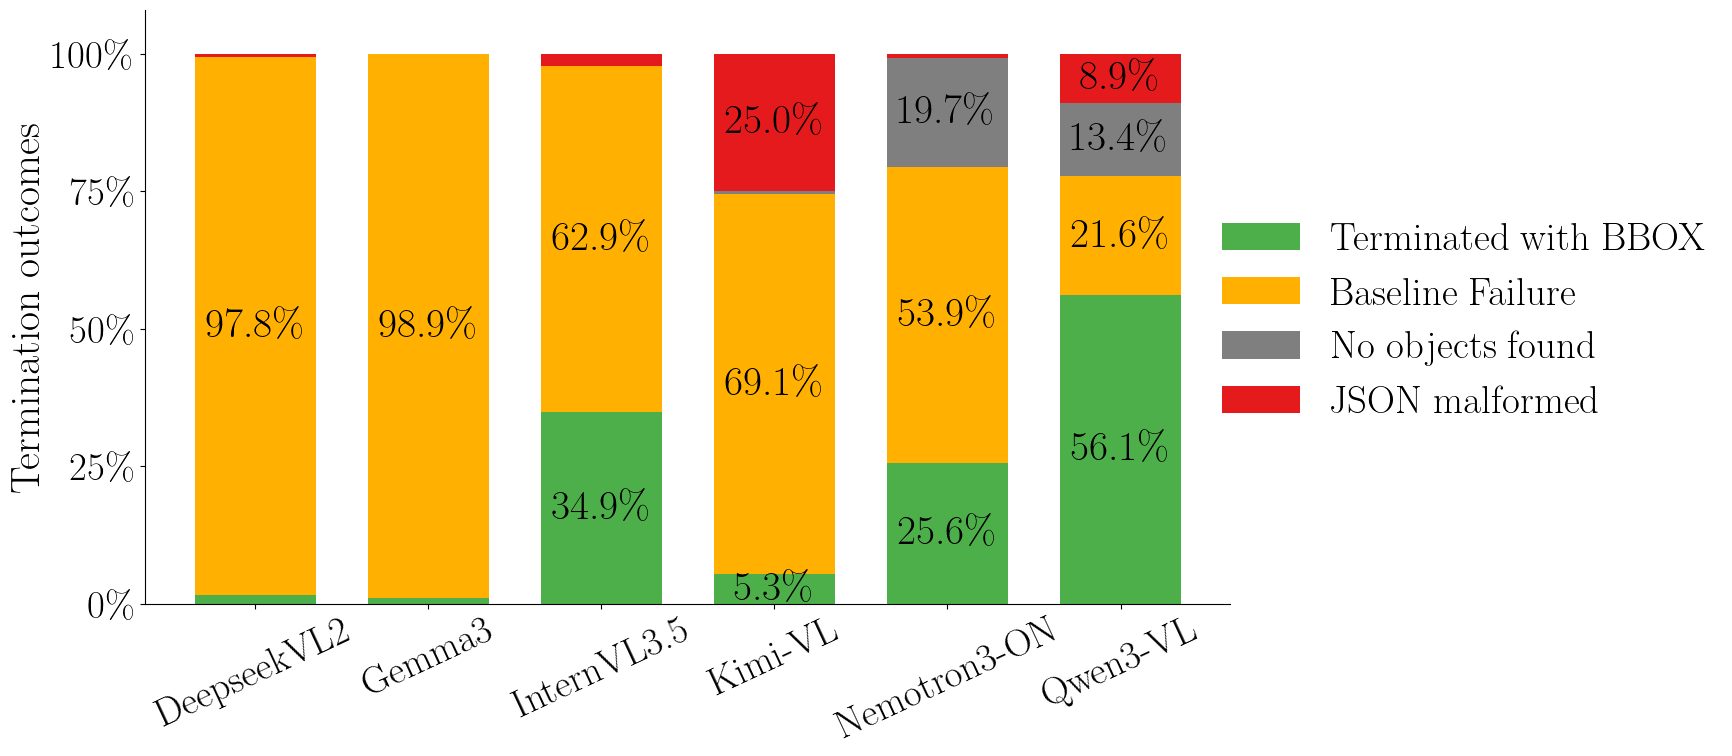

In [3]:
term_df = classify_termination_series(df_all)
models = sorted(term_df["model"].dropna().unique())

TEXT_SIZE = 30
TICK_SIZE = 28
LEGEND_SIZE = 28

fig, ax = plt.subplots(
    figsize=(14, 9)
)

x = np.arange(len(models))
bottom = np.zeros(len(models))

present_labels = [
    label
    for label in TERMINATION_ORDER
    if label in set(term_df["termination_type"].dropna())
]

for label in present_labels:

    percentages = []

    for model in models:
        sub = term_df[term_df["model"] == model]

        counts = sub["termination_type"].value_counts()
        total = counts.sum()

        value = counts.get(label, 0)

        percentage = (
            100.0 * value / total
            if total > 0
            else 0
        )

        percentages.append(percentage)

    percentages = np.array(percentages)

    bars = ax.bar(
        x,
        percentages,
        bottom=bottom,
        color=TERMINATION_COLORS[label],
        width=0.7,
        label=label,
    )

    # percentage labels inside segments
    for i, (bar, percentage) in enumerate(
        zip(bars, percentages)
    ):
        if percentage >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + percentage / 2,
                f"{percentage:.1f}\\%",
                ha="center",
                va="center",
                fontsize=TEXT_SIZE,
            )

    bottom += percentages

ax.set_ylim(0, 108)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(
    [r"0\%", r"25\%", r"50\%", r"75\%", r"100\%"],
    fontsize=TICK_SIZE,
)

ax.set_xticks(x)
ax.set_xticklabels(
    [tex(MODEL_MAPPING[m]) for m in models],
    fontsize=TICK_SIZE, rotation=25,
)

ax.set_ylabel(
    "Termination outcomes",
    fontsize=TEXT_SIZE,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    bbox_to_anchor=(0.96, 0.7),
    fontsize=LEGEND_SIZE,
    frameon=False,
)

fig.subplots_adjust(
    bottom=0.22,
)

plt.savefig(
    "figures/termination_bars.pdf",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [3]:
filtered = effectiveness_df[effectiveness_df["fail_rate"] <= 0.9]

In [4]:
from experiments._analysis import MetricTable

In [5]:
effectiveness_df["manipulation"] = effectiveness_df["genome_mode"].map(
    {
        "multi": r"\faImage\;+ \faFont",
        "image": r"\faImage",
        "text": r"\faFont",
    }
)
table = MetricTable(effectiveness_df, title="Effectiveness",
                    model_mapping= {k: v for k, v in MODEL_MAPPING.items() if k in effectiveness_df["model"].unique()},
                    scene_mapping={d: d for d in effectiveness_df["scene"].unique()},
                    metric_mapping={
                        "n_opt": "n (optimized)",
                        "baseline_fail": "BL Fail",
                        "manipulation": "Manipulation",
                        "asr_bbox": "ASR BBOX",
                        "asr_bbox_empty": "ASR BBOX+Empty",
                        "asr_bbox_empty_malformed": "ASR BBOX+Empty+Malformed",
                        "ssim": r"SSIM$\uparrow$",
                        "ned": r"NED$\downarrow$",
                        "swad": r"SWAD$\uparrow$",
                    },
                    )


In [6]:
print(table)

\begin{tabular}{llccccccccc}
\toprule
Model & Scene & n (optimized) & BL Fail & Manipulation & ASR BBOX & ASR BBOX+Empty & ASR BBOX+Empty+Malformed & SSIM$\uparrow$ & NED$\downarrow$ & SWAD$\uparrow$ \\
\midrule
\multirow{12}{*}{Qwen3-VL} & \multirow{3}{*}{Driving} & 10 & 0.82 (46/56) & \faImage\;+ \faFont & 0.60 (6/10) & 0.90 (9/10) & 1.00 (10/10) & $0.96 \pm 0.04$ & $0.002 \pm 0.001$ & $0.773 \pm 0.146$ \\
 &  & 10 & 0.82 (46/56) & \faImage & 1.00 (10/10) & 1.00 (10/10) & 1.00 (10/10) & $0.95 \pm 0.04$ & --- & $0.403 \pm 0.298$ \\
 &  & 10 & 0.82 (46/56) & \faFont & 0.70 (7/10) & 1.00 (10/10) & 1.00 (10/10) & --- & $0.085 \pm 0.141$ & $0.803 \pm 0.192$ \\
\cmidrule(lr){2-11}
 & \multirow{3}{*}{MC} & 80 & 0.20 (20/100) & \faImage\;+ \faFont & 0.68 (54/80) & 0.75 (60/80) & 1.00 (80/80) & $0.94 \pm 0.05$ & $0.211 \pm 0.169$ & $0.615 \pm 0.207$ \\
 &  & 80 & 0.20 (20/100) & \faImage & 0.80 (64/80) & 0.81 (65/80) & 1.00 (80/80) & $0.92 \pm 0.06$ & --- & $0.392 \pm 0.309$ \\
 &  & 80 & 0.2